In [13]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path("/content/drive/MyDrive/wakacyjne/llm/01") # change to path folder with data

# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

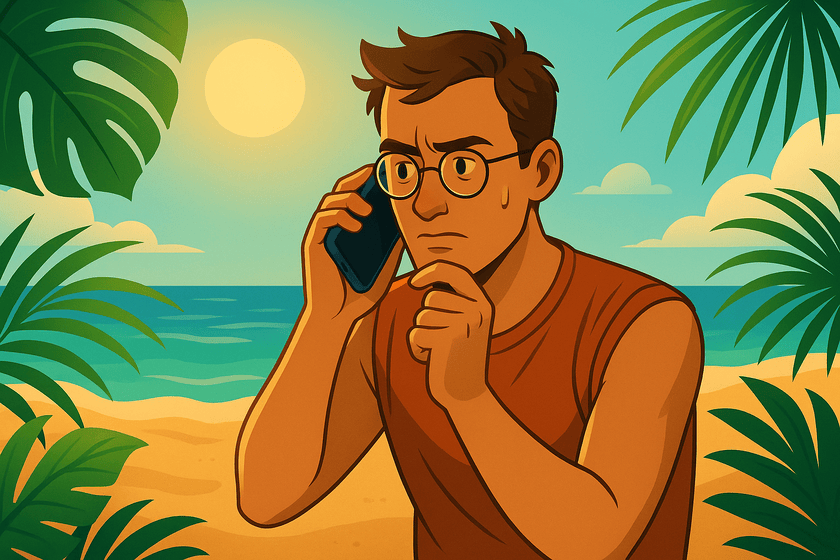

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [15]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [16]:
titanic_df.Survived.value_counts(normalize=True)

,proportion
Survived,
0,0.616162
1,0.383838


In [17]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [18]:
titanic_df.loc[1:10]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,NaN,NaN,S


- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących
wartości (sekcja #2.1)

In [19]:
def get_percentage_missing(df, axis):
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]

In [20]:
missing_cols = get_percentage_missing(titanic_df, axis=0)
missing_cols

,0
Age,19.87
Fare,11.00
Cabin,77.10
Embarked,0.22


*   Kolumna **Cabin** nie posiada 77% danych a nie pomaga nam w ustaleniu klasyfikacji pasażera
*   Kolumna **Age** może okazać się bardzo istotna w klasyfikacji ofiar dlatego warto ją uzuepłnić, zastosuje do tego medianę  
*  Kolumna **Fare** uważam, że jest mało istotna do klasyfikacji ofiar, lepsza będzie już **Pclass**, jednakże z racji na mały brak danych można również użyć mediany
*   Kolumna **Embarked**, tak samo jak **Fare** myślę, że będzie mało użyteczna do klasyfikacji, jednakże brakujące dane to bardzo mały odsetek stąd warto ją zostawić a brakujące dane uzupełnić najczęściej występującym portem




In [21]:
titanic_df = titanic_df.drop(columns=['Cabin'])

age_median = titanic_df['Age'].median()
titanic_df['Age'] = titanic_df['Age'].fillna(age_median)

fare_median = titanic_df['Fare'].median()
titanic_df['Fare'] = titanic_df['Fare'].fillna(fare_median)

embarked_mode = titanic_df['Embarked'].mode()[0]
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(embarked_mode)

get_percentage_missing(titanic_df, axis=0)
get_percentage_missing

<function __main__.get_percentage_missing(df, axis)>

Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)

Przydatnymi informacjami mogą być rozmiar rodziny poprzez zsumowanie liczby rozdzeństwa/małżonków z liczbą rodziców/dzieci oraz konkretnym pasażerem

Oraz informacja na podstawie nowej kolumny czy pasażer podróżował samotnie czy jednak z kimś

In [22]:
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

titanic_df['IsAlone'] = (titanic_df['FamilySize'] == 1).astype(int)

titanic_df[['FamilySize', 'IsAlone']].head()

,FamilySize,IsAlone
PassengerId,,
1,2,0
2,2,0
3,1,1
4,2,0
5,1,1


Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)

In [23]:
titanic_df.loc[0:10]

titanic_df['Embarked'].unique()

titanic_df['Sex'].unique()

array(['male', 'female'], dtype=object)

Kolumny które muszę zakodować to Name, Sex, Ticket oraz Embarked. Po namyśleniu się kolumny Name i Ticket może być ciężko zakodować a w przypadku przeżywalności pasażerów nie są zbytnio istotne dlatego lepiej je usunąć niż szukać pomysłu jak je zakodować poprawnie. Za to pozostałe kolumny Sex oraz Embarked można łatwo zakodować
*   **Sex** można rozbić binarnie 0 jako male i 1 jako female
*   **Embarked** można rozbić tak jak na wykładzie, czyli utworzenie 3 unikalnych kolumn (bo tyle jest unikalnych portów) i dla każdego wiersza postawić 1 przy odpowiednim porcie a 0 przy reszcie



In [24]:
from sklearn.preprocessing import OneHotEncoder
titanic_df = titanic_df.drop(columns=['Name', 'Ticket'])

titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

encoder = OneHotEncoder(sparse_output=False)
embarked_encoded = encoder.fit_transform(titanic_df[['Embarked']])
embarked_df = pd.DataFrame(embarked_encoded,
                           columns=encoder.get_feature_names_out(['Embarked']),
                           index=titanic_df.index)
titanic_df = pd.concat([titanic_df, embarked_df], axis=1)
titanic_df = titanic_df.drop('Embarked', axis=1)

titanic_df.loc[0:10]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,2,0,0.0,0.0,1.0
2,1,1,1,38.0,1,0,71.2833,2,0,1.0,0.0,0.0
3,1,3,1,26.0,0,0,7.9250,1,1,0.0,0.0,1.0
4,1,1,1,35.0,1,0,53.1000,2,0,0.0,0.0,1.0
5,0,3,0,35.0,0,0,8.0500,1,1,0.0,0.0,1.0
6,0,3,0,28.0,0,0,8.4583,1,1,0.0,1.0,0.0
7,0,1,0,54.0,0,0,51.8625,1,1,0.0,0.0,1.0
8,0,3,0,2.0,3,1,21.0750,5,0,0.0,0.0,1.0
9,1,3,1,27.0,0,2,14.5000,3,0,0.0,0.0,1.0


Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych

Outlinerów za pomocą wzorów z wykładu myślę, że najlepiej będzie szukać w niewszystkich kolumnach, ponieważ takie kolumny jak Sex albo Pclass itp. mają sztywno ustawione wartości jakie mogą wystąpić, takie jakby kategorie do każdego numeru więc tam nie powinno nic odstawać. Za to w Age, Fare, FamilySize i Parch mogą wystąpić odskocznie

In [25]:
def count_outliers_iqr(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[(df[column] < lower) | (df[column] > upper)]
  return len(outliers)

print(f"Liczba outlierów w kolumnie 'Age': {count_outliers_iqr(titanic_df, 'Age')}")
print(f"Liczba outlierów w kolumnie 'Parch': {count_outliers_iqr(titanic_df, 'Parch')}")
print(f"Liczba outlierów w kolumnie 'Fare': {count_outliers_iqr(titanic_df, 'Fare')}")
print(f"Liczba outlierów w kolumnie 'FamilySize': {count_outliers_iqr(titanic_df, 'FamilySize')}")


Liczba outlierów w kolumnie 'Age': 66
Liczba outlierów w kolumnie 'Parch': 213
Liczba outlierów w kolumnie 'Fare': 110
Liczba outlierów w kolumnie 'FamilySize': 91


Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)

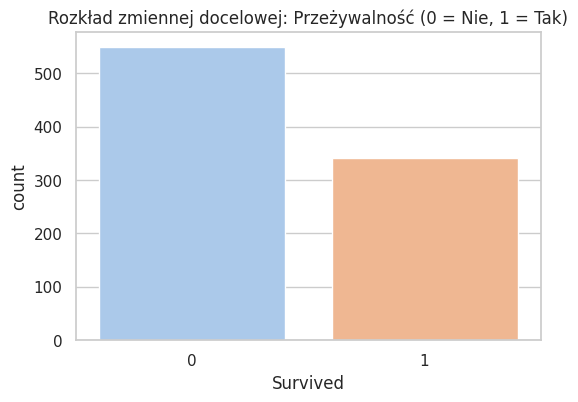

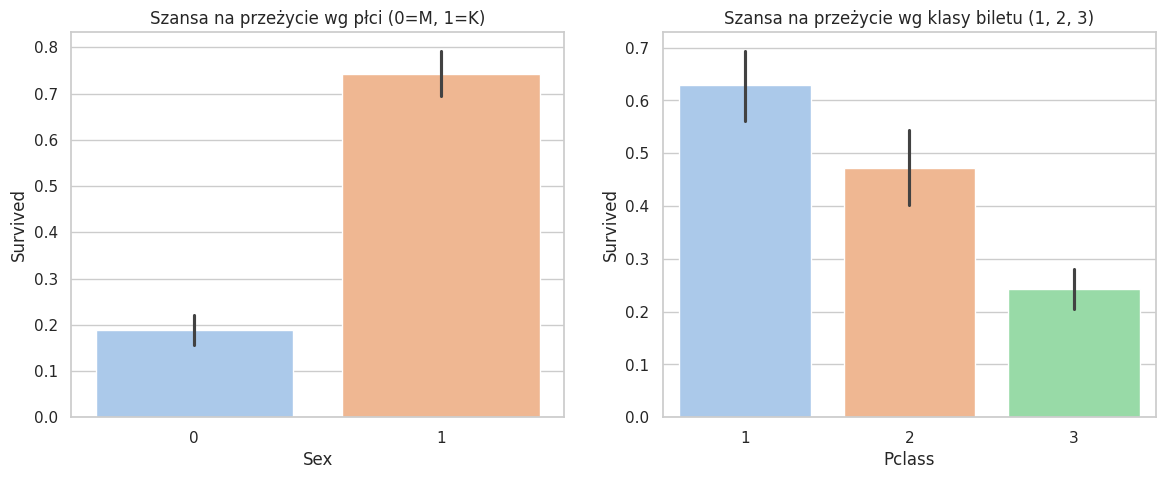

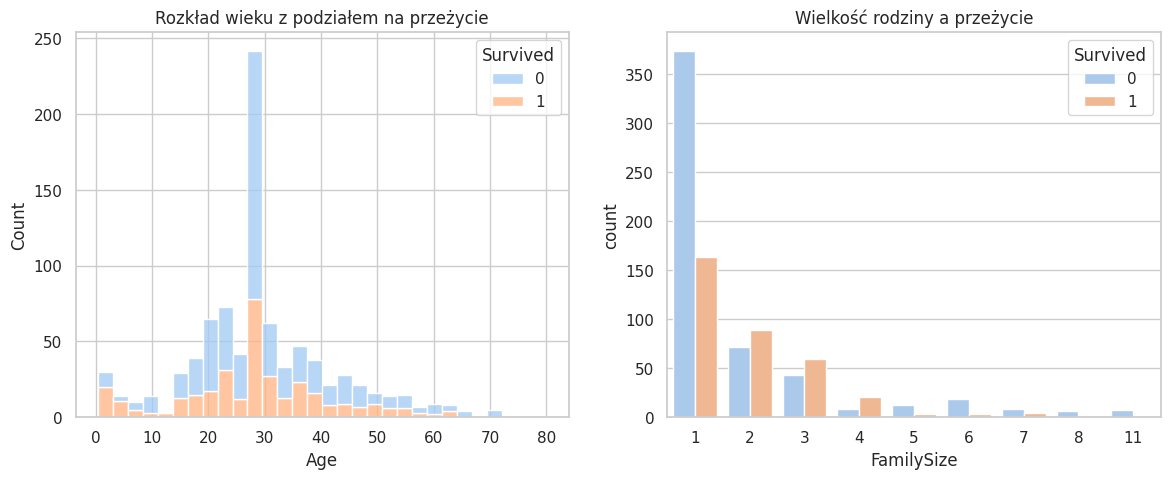

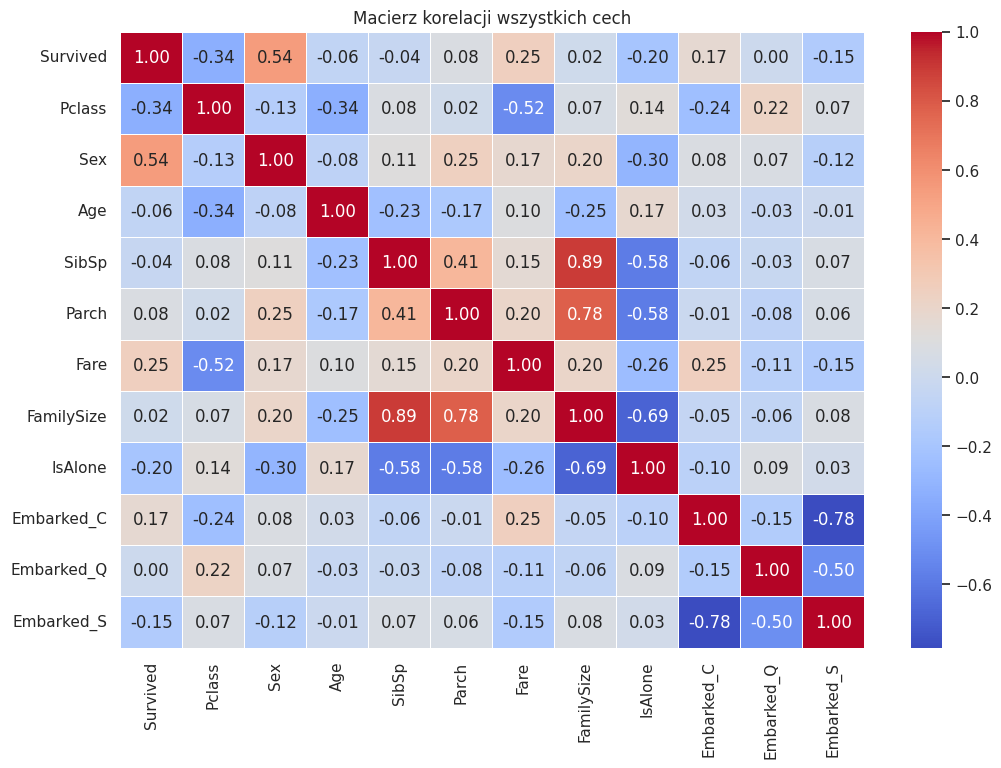

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(data=titanic_df, x='Survived', hue='Survived', palette='pastel', legend=False)
plt.title('Rozkład zmiennej docelowej: Przeżywalność (0 = Nie, 1 = Tak)')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=titanic_df, x='Sex', y='Survived', hue='Sex', ax=axes[0], palette='pastel', legend=False)
axes[0].set_title('Szansa na przeżycie wg płci (0=M, 1=K)')

sns.barplot(data=titanic_df, x='Pclass', y='Survived', hue='Pclass', ax=axes[1], palette='pastel', legend=False)
axes[1].set_title('Szansa na przeżycie wg klasy biletu (1, 2, 3)')
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=titanic_df, x='Age', hue='Survived', multiple='stack', bins=30, palette='pastel', ax=axes[0])
axes[0].set_title('Rozkład wieku z podziałem na przeżycie')

sns.countplot(data=titanic_df, x='FamilySize', hue='Survived', palette='pastel', ax=axes[1])
axes[1].set_title('Wielkość rodziny a przeżycie')
plt.show()

plt.figure(figsize=(12, 8))
corr_matrix = titanic_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji wszystkich cech')
plt.show()